# 04 Models - Tala Part

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.tree import DecisionTreeClassifier

In [ ]:
RANDOM_STATE = 42
TARGET_COL = "DEATH_EVENT"

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

TABLES_DIR = PROJECT_ROOT / "results" / "tables"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Tables folder:", TABLES_DIR)
print("Metrics folder:", METRICS_DIR)
print("Figures folder:", FIGURES_DIR)

Project root: c:\Users\talak\Desktop\CS439 Final Project\CS439-Project
Tables folder: c:\Users\talak\Desktop\CS439 Final Project\CS439-Project\results\tables
Metrics folder: c:\Users\talak\Desktop\CS439 Final Project\CS439-Project\results\metrics
Figures folder: c:\Users\talak\Desktop\CS439 Final Project\CS439-Project\results\figures


In [ ]:
def load_table(file_name: str) -> pd.DataFrame:
    file_path = TABLES_DIR / file_name
    if not file_path.exists():
        raise FileNotFoundError(f"Missing file: {file_path}")
    return pd.read_csv(file_path)


def load_y(file_name: str) -> pd.Series:
    file_path = TABLES_DIR / file_name
    if not file_path.exists() or file_path.stat().st_size == 0:
        raise FileNotFoundError(f"Missing y file: {file_path}")
    y_df = pd.read_csv(file_path)
    if TARGET_COL in y_df.columns:
        y = y_df[TARGET_COL]
    else:
        y = y_df.iloc[:, -1]
    return y.astype(int).reset_index(drop=True)


def evaluate_model(model, X_test: pd.DataFrame, y_test: pd.Series, model_name: str, time_version: str) -> dict:
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        "model": model_name,
        "time_version": time_version,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }


def save_confusion_matrix(model, X_test: pd.DataFrame, y_test: pd.Series, file_stem: str) -> None:
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survived", "Death"])
    disp.plot()
    plt.title(file_stem.replace("_", " " ).title())
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"confusion_matrix_{file_stem}.png", dpi=300)
    plt.show()


def save_roc_curve(model, X_test: pd.DataFrame, y_test: pd.Series, file_stem: str) -> None:
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(file_stem.replace("_", " " ).title())
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"roc_{file_stem}.png", dpi=300)
    plt.show()

## Load data

These CSV files were prepared earlier in the workflow.

In [ ]:
X_train_tree_with_time = load_table("X_train_tree_with_time.csv")
X_test_tree_with_time = load_table("X_test_tree_with_time.csv")
X_train_tree_without_time = load_table("X_train_tree_without_time.csv")
X_test_tree_without_time = load_table("X_test_tree_without_time.csv")

X_train_gb_with_time = load_table("X_train_gb_with_time.csv")
X_test_gb_with_time = load_table("X_test_gb_with_time.csv")
X_train_gb_without_time = load_table("X_train_gb_without_time.csv")
X_test_gb_without_time = load_table("X_test_gb_without_time.csv")

y_train = load_y("y_train.csv")
y_test = load_y("y_test.csv")

print("Decision Tree with time:", X_train_tree_with_time.shape, X_test_tree_with_time.shape)
print("Decision Tree without time:", X_train_tree_without_time.shape, X_test_tree_without_time.shape)
print("Gradient Boosting with time:", X_train_gb_with_time.shape, X_test_gb_with_time.shape)
print("Gradient Boosting without time:", X_train_gb_without_time.shape, X_test_gb_without_time.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Decision Tree with time: (239, 12) (60, 12)
Decision Tree without time: (239, 11) (60, 11)
Gradient Boosting with time: (239, 12) (60, 12)
Gradient Boosting without time: (239, 11) (60, 11)
y_train: (239,)
y_test: (60,)


In [ ]:
assert len(X_train_tree_with_time) == len(y_train)
assert len(X_train_tree_without_time) == len(y_train)
assert len(X_train_gb_with_time) == len(y_train)
assert len(X_train_gb_without_time) == len(y_train)

assert len(X_test_tree_with_time) == len(y_test)
assert len(X_test_tree_without_time) == len(y_test)
assert len(X_test_gb_with_time) == len(y_test)
assert len(X_test_gb_without_time) == len(y_test)

print("Basic shape checks passed.")

Basic shape checks passed.


## Decision Tree

Decision Tree gives a simple rule-based baseline that is easy to explain.

In [ ]:
decision_tree_with_time = DecisionTreeClassifier(
    max_depth=4,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

decision_tree_with_time.fit(X_train_tree_with_time, y_train)
decision_tree_with_time_results = evaluate_model(
    decision_tree_with_time,
    X_test_tree_with_time,
    y_test,
    model_name="Decision Tree",
    time_version="with_time",
)
decision_tree_with_time_results

{'model': 'Decision Tree',
 'time_version': 'with_time',
 'accuracy': 0.7833333333333333,
 'precision': 0.6363636363636364,
 'recall': 0.7368421052631579,
 'f1': 0.6829268292682927,
 'roc_auc': 0.7779204107830552}

In [ ]:
print(classification_report(
    y_test,
    decision_tree_with_time.predict(X_test_tree_with_time),
    target_names=["Survived", "Death"],
    zero_division=0,
))

              precision    recall  f1-score   support

    Survived       0.87      0.80      0.84        41
       Death       0.64      0.74      0.68        19

    accuracy                           0.78        60
   macro avg       0.75      0.77      0.76        60
weighted avg       0.79      0.78      0.79        60



In [ ]:
decision_tree_without_time = DecisionTreeClassifier(
    max_depth=4,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

decision_tree_without_time.fit(X_train_tree_without_time, y_train)
decision_tree_without_time_results = evaluate_model(
    decision_tree_without_time,
    X_test_tree_without_time,
    y_test,
    model_name="Decision Tree",
    time_version="without_time",
)
decision_tree_without_time_results

{'model': 'Decision Tree',
 'time_version': 'without_time',
 'accuracy': 0.7166666666666667,
 'precision': 0.5384615384615384,
 'recall': 0.7368421052631579,
 'f1': 0.6222222222222222,
 'roc_auc': 0.7439024390243901}

In [ ]:
print(classification_report(
    y_test,
    decision_tree_without_time.predict(X_test_tree_without_time),
    target_names=["Survived", "Death"],
    zero_division=0,
))

              precision    recall  f1-score   support

    Survived       0.85      0.71      0.77        41
       Death       0.54      0.74      0.62        19

    accuracy                           0.72        60
   macro avg       0.70      0.72      0.70        60
weighted avg       0.75      0.72      0.73        60



## Decision Tree plots

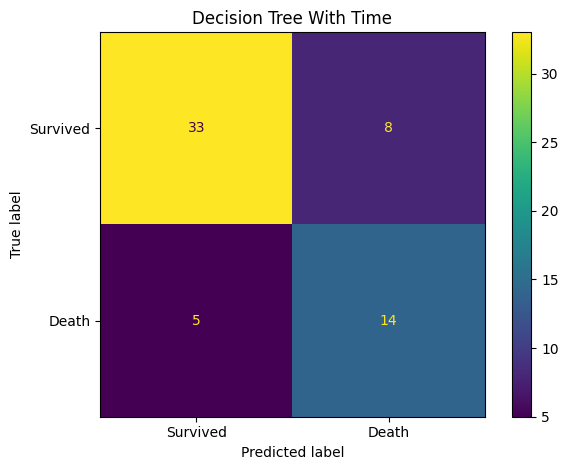

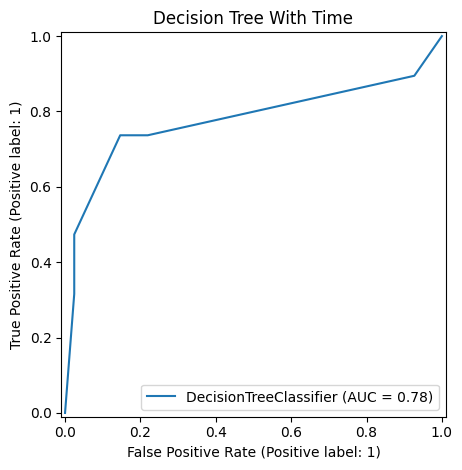

In [ ]:
save_confusion_matrix(
    decision_tree_with_time,
    X_test_tree_with_time,
    y_test,
    "decision_tree_with_time",
)
save_roc_curve(
    decision_tree_with_time,
    X_test_tree_with_time,
    y_test,
    "decision_tree_with_time",
)

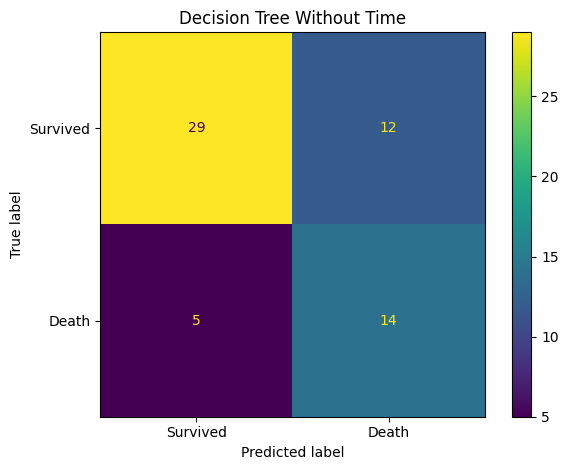

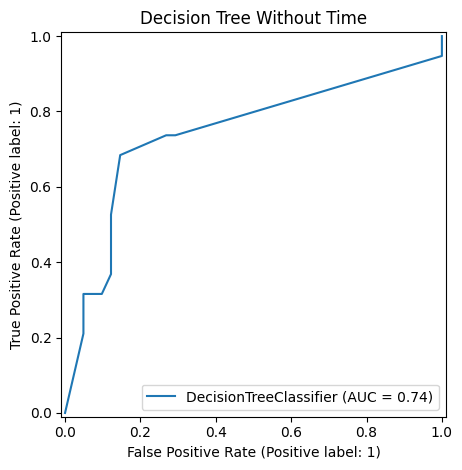

In [ ]:
save_confusion_matrix(
    decision_tree_without_time,
    X_test_tree_without_time,
    y_test,
    "decision_tree_without_time",
)
save_roc_curve(
    decision_tree_without_time,
    X_test_tree_without_time,
    y_test,
    "decision_tree_without_time",
)

## Gradient Boosting

Gradient Boosting is a stronger tree-based model that combines many small trees.

In [ ]:
gradient_boosting_with_time = GradientBoostingClassifier(
    random_state=RANDOM_STATE,
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
)

gradient_boosting_with_time.fit(X_train_gb_with_time, y_train)
gradient_boosting_with_time_results = evaluate_model(
    gradient_boosting_with_time,
    X_test_gb_with_time,
    y_test,
    model_name="Gradient Boosting",
    time_version="with_time",
)
gradient_boosting_with_time_results

{'model': 'Gradient Boosting',
 'time_version': 'with_time',
 'accuracy': 0.8333333333333334,
 'precision': 0.8,
 'recall': 0.631578947368421,
 'f1': 0.7058823529411765,
 'roc_auc': 0.8677792041078304}

In [ ]:
print(classification_report(
    y_test,
    gradient_boosting_with_time.predict(X_test_gb_with_time),
    target_names=["Survived", "Death"],
    zero_division=0,
))

              precision    recall  f1-score   support

    Survived       0.84      0.93      0.88        41
       Death       0.80      0.63      0.71        19

    accuracy                           0.83        60
   macro avg       0.82      0.78      0.79        60
weighted avg       0.83      0.83      0.83        60



In [ ]:
gradient_boosting_without_time = GradientBoostingClassifier(
    random_state=RANDOM_STATE,
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
)

gradient_boosting_without_time.fit(X_train_gb_without_time, y_train)
gradient_boosting_without_time_results = evaluate_model(
    gradient_boosting_without_time,
    X_test_gb_without_time,
    y_test,
    model_name="Gradient Boosting",
    time_version="without_time",
)
gradient_boosting_without_time_results

{'model': 'Gradient Boosting',
 'time_version': 'without_time',
 'accuracy': 0.7,
 'precision': 0.5384615384615384,
 'recall': 0.3684210526315789,
 'f1': 0.4375,
 'roc_auc': 0.766367137355584}

In [ ]:
print(classification_report(
    y_test,
    gradient_boosting_without_time.predict(X_test_gb_without_time),
    target_names=["Survived", "Death"],
    zero_division=0,
))

              precision    recall  f1-score   support

    Survived       0.74      0.85      0.80        41
       Death       0.54      0.37      0.44        19

    accuracy                           0.70        60
   macro avg       0.64      0.61      0.62        60
weighted avg       0.68      0.70      0.68        60



## Gradient Boosting plots

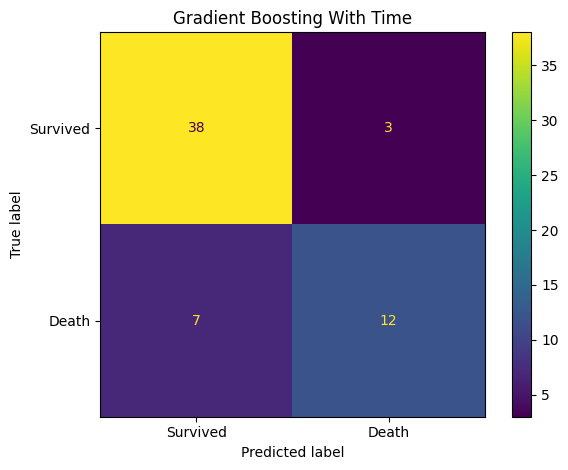

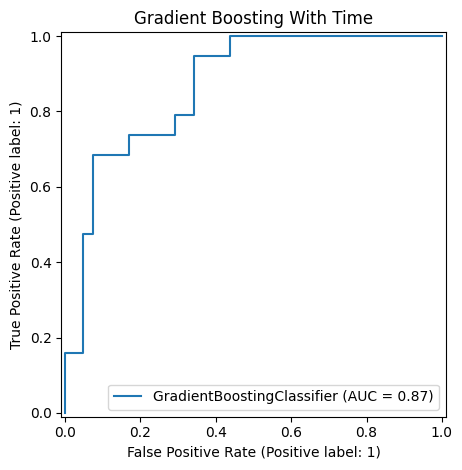

In [ ]:
save_confusion_matrix(
    gradient_boosting_with_time,
    X_test_gb_with_time,
    y_test,
    "gradient_boosting_with_time",
)
save_roc_curve(
    gradient_boosting_with_time,
    X_test_gb_with_time,
    y_test,
    "gradient_boosting_with_time",
)

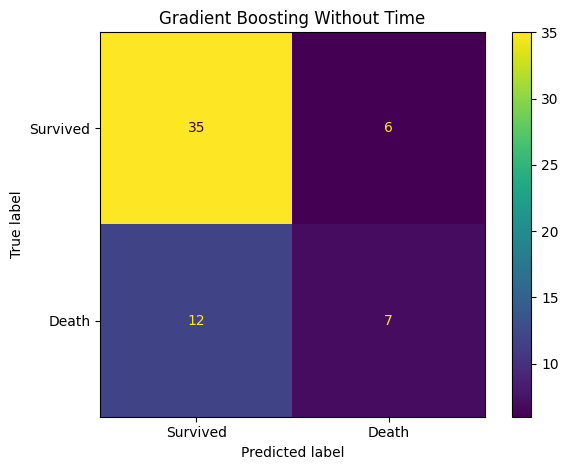

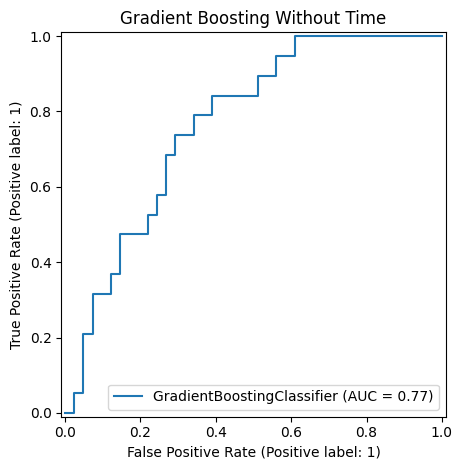

In [ ]:
save_confusion_matrix(
    gradient_boosting_without_time,
    X_test_gb_without_time,
    y_test,
    "gradient_boosting_without_time",
)
save_roc_curve(
    gradient_boosting_without_time,
    X_test_gb_without_time,
    y_test,
    "gradient_boosting_without_time",
)

## results summary

This table is the main output from this notebook.

In [ ]:
tala_results = pd.DataFrame([
    decision_tree_with_time_results,
    decision_tree_without_time_results,
    gradient_boosting_with_time_results,
    gradient_boosting_without_time_results,
])

tala_results = tala_results[[
    "model",
    "time_version",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
]]

tala_results_path = METRICS_DIR / "tala_decisiontree_gradientboosting_metrics.csv"
tala_results.to_csv(tala_results_path, index=False)

print("Saved Tala results to:", tala_results_path)
tala_results

Saved Tala results to: c:\Users\talak\Desktop\CS439 Final Project\CS439-Project\results\metrics\tala_decisiontree_gradientboosting_metrics.csv


,model,time_version,accuracy,precision,recall,f1,roc_auc
0,Decision Tree,with_time,0.783333,0.636364,0.736842,0.682927,0.777920
1,Decision Tree,without_time,0.716667,0.538462,0.736842,0.622222,0.743902
2,Gradient Boosting,with_time,0.833333,0.800000,0.631579,0.705882,0.867779
3,Gradient Boosting,without_time,0.700000,0.538462,0.368421,0.437500,0.766367
